# Analyze HPO Results — YOLO26-seg fine-tuning no ISIC 2018 Task 1

Notebook que carrega os resultados do `tune_all_models.py` (HPO sequencial
nos 5 tamanhos do YOLO26-seg) e responde:

1. **Convergência da busca**: quantas iterações cada tamanho levou para
   chegar ao plateau? O GA está realmente melhorando ou platôs em ruído?
2. **Best fitness por tamanho**: qual modelo se beneficiou mais do tuning?
3. **Hp campeões por tamanho**: tabela ready-to-use por modelo.
4. **Distribuições por trial**: o GA convergiu (variância caiu) ou ainda
   estava explorando?
5. **Correlação hp × fitness**: quais hp realmente importam vs quais o GA
   variou sem efeito mensurável?
6. **Heatmap hp normalizado**: padrões entre modelos (pequenos preferem
   `lr0` maior? augmentação mais agressiva? etc).
7. **Δ vs default v7**: o quão longe o tuning levou cada hp do default
   que vínhamos usando.

## 1. Setup

In [52]:
import json
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display, Markdown
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

# ----- estilo global ---------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "legend.fontsize": 10,
})
sns.set_context("notebook", font_scale=1.0)

# ----- paleta por tamanho de modelo (Okabe-Ito ordenada cool→warm) ----------
MODEL_PALETTE = {
    "Nano":   "#56B4E9",  # sky blue
    "Small":  "#0072B2",  # blue
    "Medium": "#009E73",  # green
    "Large":  "#E69F00",  # orange
    "XLarge": "#D55E00",  # vermillion
}
MODEL_ORDER = list(MODEL_PALETTE)
print("Setup OK — palette:", MODEL_ORDER)


Setup OK — palette: ['Nano', 'Small', 'Medium', 'Large', 'XLarge']


### 1.1 Path configuration

In [53]:
# Mude `unb_server` conforme o ambiente.
unb_server = True

if unb_server:
    BASE_DIR = Path("/home/antoniovinicius/projects/sandbox_yolo26")
else:
    BASE_DIR = Path("/home/avmoura_linux/Documents/unb/sandbox_yolo26")

# Convenção: cada modelo gera uma pasta tune_isic_2018_task_1_<model>.
# Edite aqui se renomear ou se for analisar tunings de color spaces alternativos.
TUNE_DIRS = {
    "Nano":   BASE_DIR / "logs" / "hpo" / "hpo_v3" / "tune_isic_2018_task_1_nano",
    "Small":  BASE_DIR / "logs" / "hpo" / "hpo_v3" / "tune_isic_2018_task_1_small",
    "Medium": BASE_DIR / "logs" / "hpo" / "hpo_v3" / "tune_isic_2018_task_1_medium",
    "Large":  BASE_DIR / "logs" / "hpo" / "hpo_v3" / "tune_isic_2018_task_1_large",
    "XLarge": BASE_DIR / "logs" / "hpo" / "hpo_v3" / "tune_isic_2018_task_1_xlarge",
}
print("Tune dirs:")
for m, d in TUNE_DIRS.items():
    has_data = (d / "tune_results.ndjson").exists() or (d / "tune_results.csv").exists()
    flag = "✓" if has_data else "✗"
    print(f"  [{flag}] {m:7s} {d}")


Tune dirs:
  [✓] Nano    /home/antoniovinicius/projects/sandbox_yolo26/logs/hpo/hpo_v3/tune_isic_2018_task_1_nano
  [✓] Small   /home/antoniovinicius/projects/sandbox_yolo26/logs/hpo/hpo_v3/tune_isic_2018_task_1_small
  [✓] Medium  /home/antoniovinicius/projects/sandbox_yolo26/logs/hpo/hpo_v3/tune_isic_2018_task_1_medium
  [✓] Large   /home/antoniovinicius/projects/sandbox_yolo26/logs/hpo/hpo_v3/tune_isic_2018_task_1_large
  [✓] XLarge  /home/antoniovinicius/projects/sandbox_yolo26/logs/hpo/hpo_v3/tune_isic_2018_task_1_xlarge


## 2. Carga de dados — `tune_results.csv` + `best_hyperparameters.yaml`


In [54]:
def _load_ndjson(p: Path) -> pd.DataFrame:
    rows = []
    with p.open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            r = json.loads(line)
            row = {"iteration": r["iteration"], "fitness": r["fitness"]}
            row.update(r.get("hyperparameters", {}))
            rows.append(row)
    return pd.DataFrame(rows)


def _load_csv(p: Path) -> pd.DataFrame:
    df = pd.read_csv(p)
    # No CSV do Ultralytics 8.4.21 a iteração é implícita pela ordem.
    df.insert(0, "iteration", range(1, len(df) + 1))
    return df


def load_tune_run(model: str, d: Path) -> dict | None:
    """Carrega um run de tune. Detecta NDJSON ou CSV automaticamente.
    
    Retorna None se faltar dados."""
    nd = d / "tune_results.ndjson"
    cv = d / "tune_results.csv"
    yml = d / "best_hyperparameters.yaml"

    if nd.exists():
        df = _load_ndjson(nd)
        fmt = "ndjson"
    elif cv.exists():
        df = _load_csv(cv)
        fmt = "csv"
    else:
        return None

    if df.empty:
        return None
    df = df.sort_values("iteration").reset_index(drop=True)
    df["Model"] = model
    df["best_so_far"] = df["fitness"].cummax()

    best_hp = {}
    if yml.exists():
        with yml.open() as f:
            best_hp = yaml.safe_load(f) or {}
    return {"df": df, "best_hp": best_hp, "dir": d, "format": fmt}


runs = {}
for m in MODEL_ORDER:
    r = load_tune_run(m, TUNE_DIRS[m])
    if r is None:
        print(f"  [skip] {m} — sem tune_results.{{ndjson,csv}} em {TUNE_DIRS[m]}")
        continue
    runs[m] = r
    print(f"  [load] {m:7s} {len(r['df']):>3d} trials  ({r['format']:6s})  best fitness = {r['df']['fitness'].max():.4f}")

if not runs:
    raise RuntimeError("Nenhum tuning encontrado. Verifique TUNE_DIRS.")

MODELS_PRESENT = [m for m in MODEL_ORDER if m in runs]
print(f"\nModelos com dados: {MODELS_PRESENT}")

# DataFrame longo concatenando todos os trials
df_long = pd.concat([runs[m]["df"] for m in MODELS_PRESENT], ignore_index=True)
df_long["Model"] = pd.Categorical(df_long["Model"], categories=MODELS_PRESENT, ordered=True)
print(f"Total trials: {len(df_long)}")
display(df_long.head(8))


  [load] Nano     50 trials  (csv   )  best fitness = 1.4253
  [load] Small    50 trials  (csv   )  best fitness = 1.4616
  [load] Medium   50 trials  (csv   )  best fitness = 1.4571
  [load] Large    50 trials  (csv   )  best fitness = 1.4601
  [load] XLarge   35 trials  (csv   )  best fitness = 1.4396

Modelos com dados: ['Nano', 'Small', 'Medium', 'Large', 'XLarge']
Total trials: 235


,iteration,fitness,lr0,lrf,momentum,weight_decay,warmup_epochs,cls,dfl,hsv_h,hsv_s,hsv_v,translate,flipud,mosaic,mixup,copy_paste,Model,best_so_far
0,1,1.35712,0.00400,0.01000,0.93700,0.00010,3.00000,0.50000,1.50000,0.01500,0.70000,0.40000,0.10000,0.00000,1.00000,0.00000,0.00000,Nano,1.35712
1,2,1.38972,0.00400,0.00881,0.92482,0.00010,2.99757,0.47054,1.50000,0.00830,0.67675,0.42239,0.09945,0.00143,0.84937,0.00434,0.00374,Nano,1.38972
2,3,1.40846,0.00100,0.00932,0.91584,0.00000,3.39338,0.50582,1.41463,0.00500,0.90000,0.41542,0.08978,0.00478,0.70000,0.00369,0.00585,Nano,1.40846
3,4,1.40583,0.00395,0.00721,0.91632,0.00007,3.18362,0.46951,0.85976,0.01430,0.90000,0.65451,0.06236,0.00504,0.70000,0.00387,0.00457,Nano,1.40846
4,5,1.34555,0.00193,0.00851,0.92177,0.00010,3.44477,0.47146,1.11954,0.00750,0.68793,0.66650,0.11761,0.00449,0.85768,0.00407,0.00517,Nano,1.40846
5,6,1.36616,0.00304,0.01517,0.86761,0.00002,2.94276,0.47821,1.50000,0.01313,0.85396,0.65716,0.05000,0.00512,0.83688,0.00221,0.00000,Nano,1.40846
6,7,1.36307,0.00100,0.01525,0.87980,0.00000,2.90021,0.33799,0.94352,0.00925,0.90000,0.68232,0.05218,0.00268,0.71755,0.00268,0.00007,Nano,1.40846
7,8,1.36375,0.00103,0.00973,0.85256,0.00003,3.26720,0.61099,1.15146,0.01222,0.69143,0.63238,0.05449,0.00606,0.71691,0.00196,0.00402,Nano,1.40846


## 3. Curvas de fitness — convergência da busca

Linha sólida fina = fitness do trial atual. Linha grossa = `best_so_far`
(envoltória monotônica). **Plateau = busca convergiu.** Se ainda subindo
no fim, vale considerar mais iterações.


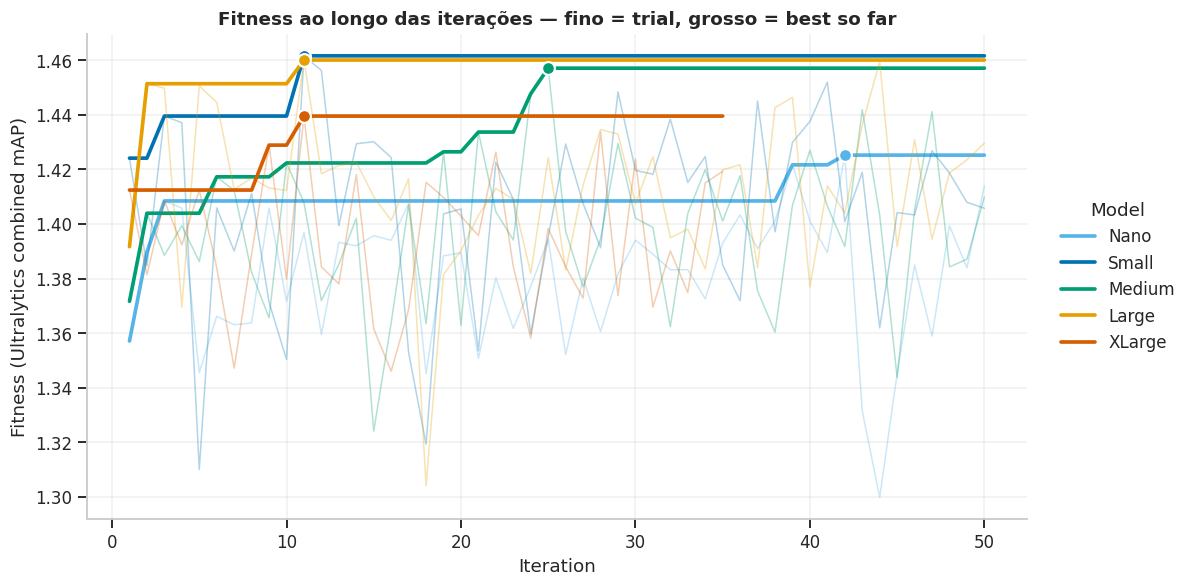

In [55]:
n = len(MODELS_PRESENT)
fig, ax = plt.subplots(figsize=(11, 5.5))
for m in MODELS_PRESENT:
    df = runs[m]["df"]
    c = MODEL_PALETTE[m]
    ax.plot(df["iteration"], df["fitness"], color=c, alpha=0.30, lw=1.0)
    ax.plot(df["iteration"], df["best_so_far"], color=c, lw=2.4, label=m)
    # marcar best
    bi = int(df["fitness"].idxmax())
    ax.scatter([df["iteration"].iloc[bi]], [df["fitness"].iloc[bi]],
               color=c, s=70, zorder=5, edgecolor="white", linewidth=1.4)
ax.set_xlabel("Iteration")
ax.set_ylabel("Fitness (Ultralytics combined mAP)")
ax.set_title("Fitness ao longo das iterações — fino = trial, grosso = best so far")
ax.grid(True, alpha=0.3)
ax.legend(title="Model", loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


In [56]:
# Tabela: best fitness, em qual iteração, e std das últimas 5 iterações (proxy de plateau)
def stats_for(df: pd.DataFrame) -> dict:
    bi = int(df["fitness"].idxmax())
    return {
        "Best fitness":      df["fitness"].max(),
        "Best iteration":    int(df["iteration"].iloc[bi]),
        "Total iterations":  int(df["iteration"].max()),
        "Std last 5 trials": float(df["fitness"].iloc[-5:].std()) if len(df) >= 5 else float("nan"),
        "Improved last 25%": bool(
            df["fitness"].iloc[-max(1, len(df)//4):].max()
            > df["fitness"].iloc[:-max(1, len(df)//4)].max()
        ) if len(df) >= 4 else False,
    }


summary_rows = [{"Model": m, **stats_for(runs[m]["df"])} for m in MODELS_PRESENT]
summary = pd.DataFrame(summary_rows).set_index("Model")
display(Markdown("### 3.1 Estatísticas de convergência"))
display(summary.style.format({
    "Best fitness": "{:.4f}",
    "Std last 5 trials": "{:.4f}",
}).background_gradient(subset=["Best fitness"], cmap="YlGn"))


### 3.1 Estatísticas de convergência

,Best fitness,Best iteration,Total iterations,Std last 5 trials,Improved last 25%
Model,,,,,
Nano,1.4253,42,50,0.0204,True
Small,1.4616,11,50,0.0099,False
Medium,1.4571,25,50,0.0228,False
Large,1.4601,11,50,0.0148,False
XLarge,1.4396,11,35,0.0227,False


## 4. Best fitness por modelo

Comparação direta. Em geral espera-se modelos maiores com fitness
maior — se invertido (ex.: nano > small), pode indicar que small ainda
não convergiu o GA, ou que augment exagerada está hurting models maiores.


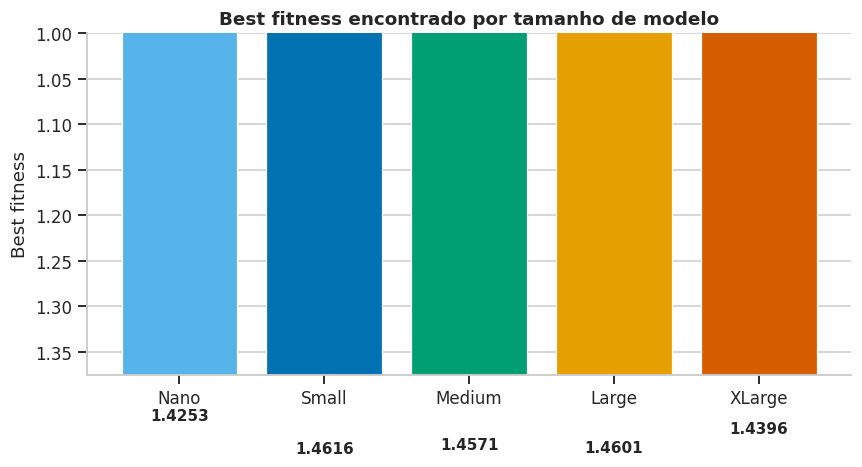

In [57]:
best_fit = pd.Series(
    {m: runs[m]["df"]["fitness"].max() for m in MODELS_PRESENT}
).reindex(MODELS_PRESENT)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(best_fit.index, best_fit.values,
              color=[MODEL_PALETTE[m] for m in best_fit.index],
              edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, best_fit.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f"{v:.4f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ymin = max(0.0, best_fit.min() - 0.05)
ax.set_ylim(ymin, min(1.0, best_fit.max() + 0.04))
ax.set_ylabel("Best fitness")
ax.set_title("Best fitness encontrado por tamanho de modelo")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()


## 5. Hp campeões por modelo (top-1)

Tabela com o conteúdo do `best_hyperparameters.yaml` de cada run. Cada
coluna = um modelo. Use direto no `train_with_tuned_hp.py`.


In [58]:
best_hp_long = []
for m in MODELS_PRESENT:
    for k, v in runs[m]["best_hp"].items():
        best_hp_long.append({"Model": m, "hp": k, "value": v})

if best_hp_long:
    best_hp_df = pd.DataFrame(best_hp_long)
    best_hp_pivot = best_hp_df.pivot(index="hp", columns="Model", values="value")
    best_hp_pivot = best_hp_pivot.reindex(columns=MODELS_PRESENT)
    display(Markdown("### 5.1 Tabela hp-campeão × modelo"))
    display(best_hp_pivot.style.format("{:.4f}", na_rep="—")
            .background_gradient(cmap="YlGnBu", axis=1))
else:
    print("Nenhum best_hyperparameters.yaml encontrado.")


### 5.1 Tabela hp-campeão × modelo

Model,Nano,Small,Medium,Large,XLarge
hp,,,,,
cls,0.6488,0.6276,0.4111,0.4605,0.3854
copy_paste,0.0011,0.0002,0.0032,0.0051,0.0110
dfl,1.5000,1.1725,1.4196,1.4018,1.3518
flipud,0.0029,0.0040,0.0069,0.0013,0.0043
hsv_h,0.0050,0.0143,0.0151,0.0115,0.0210
hsv_s,0.9000,0.6583,0.7079,0.7240,0.6277
hsv_v,0.5779,0.3549,0.4057,0.3980,0.3696
lr0,0.0025,0.0024,0.0021,0.0022,0.0038
lrf,0.0059,0.0159,0.0076,0.0168,0.0054


## 6. Distribuição dos hp ao longo dos trials por modelo

Para cada hiperparâmetro, mostra a evolução por trial (linha fina) e a
janela ±1σ deslizante (banda). **Banda estreita no fim = GA convergiu**
naquele hp; **banda ainda larga = ainda explorando**.


In [59]:
def hp_columns(df: pd.DataFrame) -> list[str]:
    """Colunas de hiperparâmetros (não meta) presentes no df."""
    skip = {"iteration", "fitness", "Model", "best_so_far"}
    return [c for c in df.columns if c not in skip]


# Hp comuns a TODOS os modelos (interseção)
hp_common = sorted(
    set.intersection(*[set(hp_columns(runs[m]["df"])) for m in MODELS_PRESENT])
) if len(MODELS_PRESENT) >= 1 else []
print(f"Hp comuns aos {len(MODELS_PRESENT)} modelos: {len(hp_common)}")

# Limitar plot a 12 hp para legibilidade (pode editar)
HP_TO_PLOT = hp_common[:12] if len(hp_common) > 12 else hp_common
print(f"Plotando: {HP_TO_PLOT}")


Hp comuns aos 5 modelos: 15
Plotando: ['cls', 'copy_paste', 'dfl', 'flipud', 'hsv_h', 'hsv_s', 'hsv_v', 'lr0', 'lrf', 'mixup', 'momentum', 'mosaic']


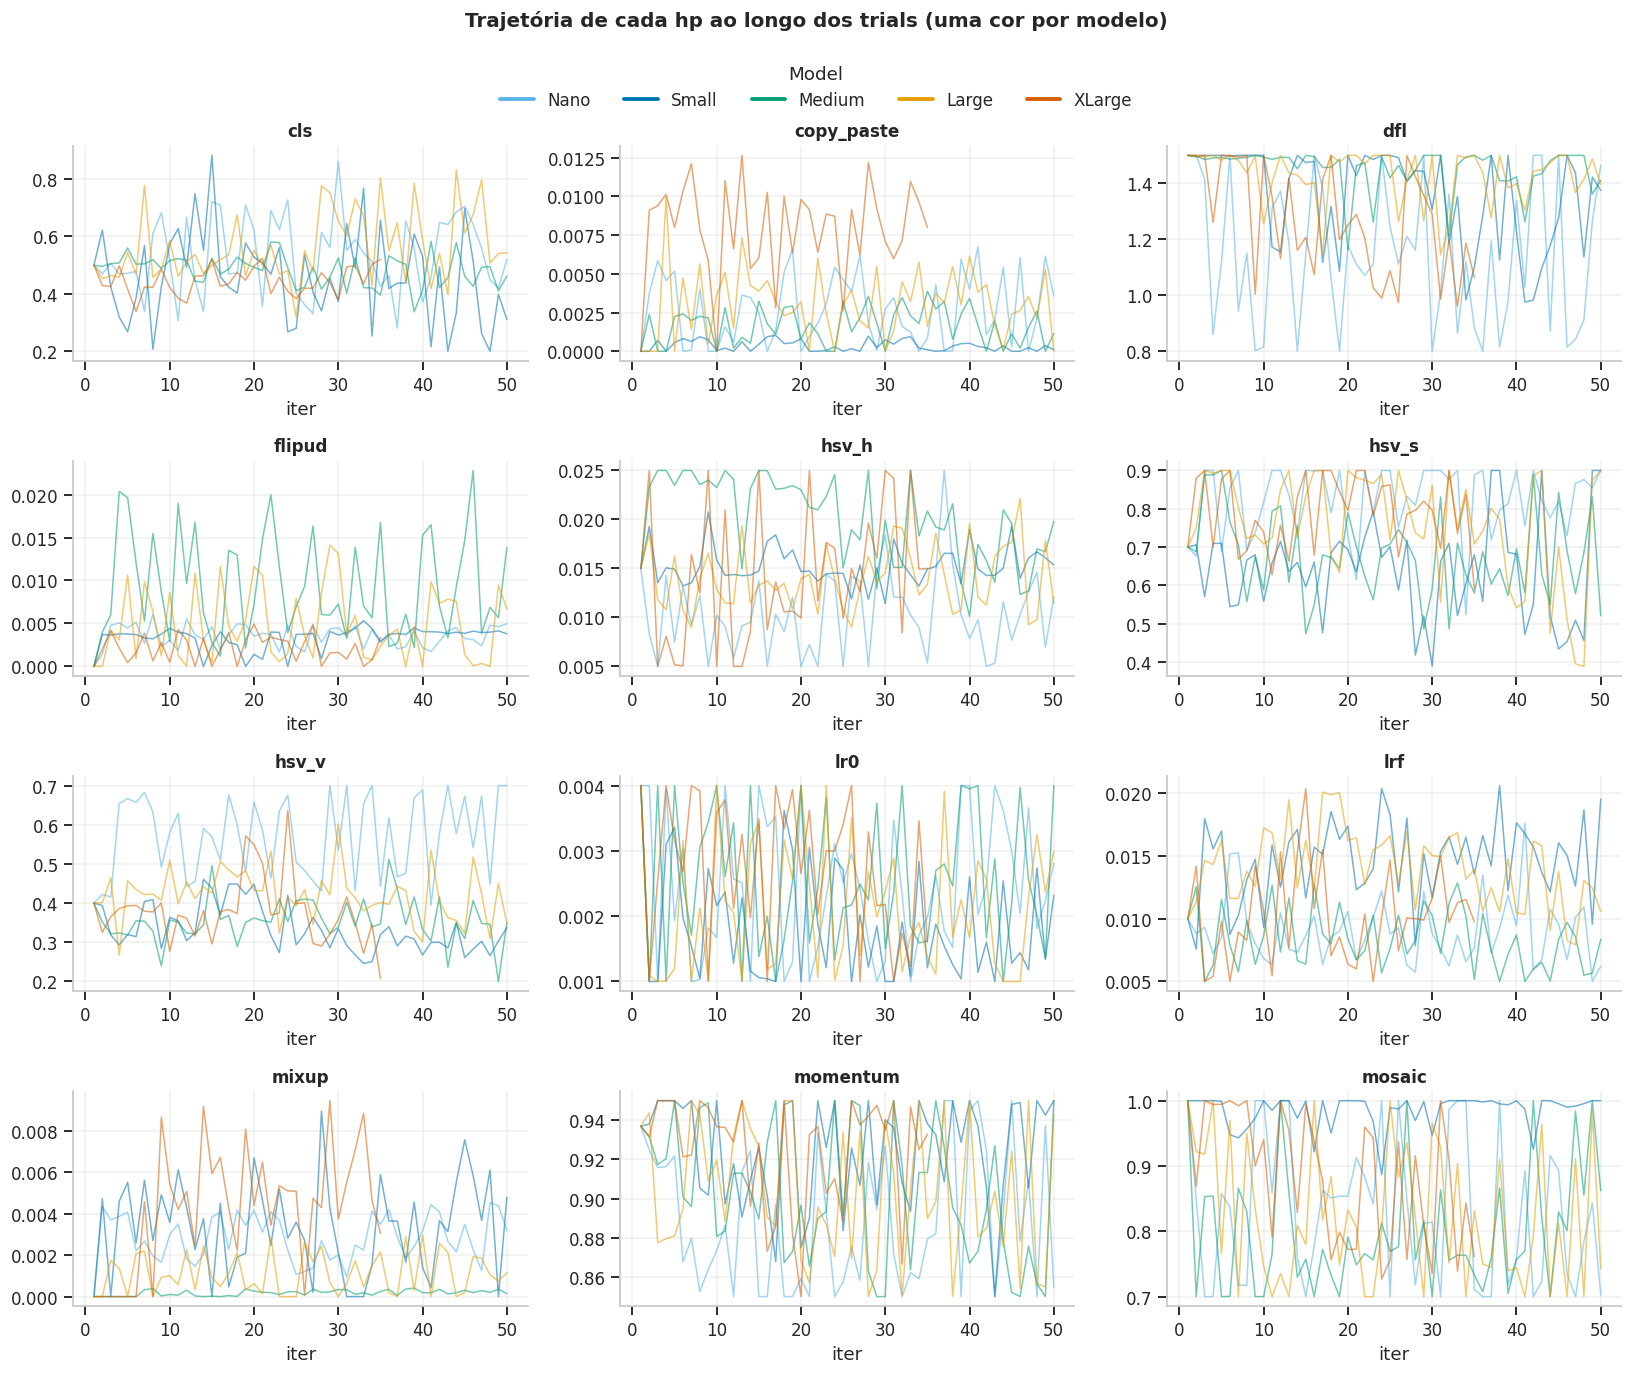

In [60]:
if HP_TO_PLOT:
    nrows = (len(HP_TO_PLOT) + 2) // 3
    fig, axes = plt.subplots(nrows, 3, figsize=(15, 3.0 * nrows), squeeze=False)
    axes_flat = axes.flatten()
    for i, hp in enumerate(HP_TO_PLOT):
        ax = axes_flat[i]
        for m in MODELS_PRESENT:
            df = runs[m]["df"]
            if hp not in df:
                continue
            c = MODEL_PALETTE[m]
            ax.plot(df["iteration"], df[hp], color=c, alpha=0.55, lw=1.0, label=m)
        ax.set_title(hp, fontsize=11)
        ax.set_xlabel("iter")
        ax.grid(True, alpha=0.3)
    for j in range(len(HP_TO_PLOT), len(axes_flat)):
        axes_flat[j].axis("off")

    handles = [plt.Line2D([0], [0], color=MODEL_PALETTE[m], lw=2.5, label=m) for m in MODELS_PRESENT]
    fig.legend(handles=handles, title="Model", loc="upper center",
               bbox_to_anchor=(0.5, 1.01), ncol=len(MODELS_PRESENT))
    fig.suptitle("Trajetória de cada hp ao longo dos trials (uma cor por modelo)",
                 y=1.04, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Sem hp comuns para plotar.")


## 7. Faixa dos top-K trials por hp

Para cada hp, distribuição dos valores nos **top 5 trials** de cada
modelo (por fitness). Mostra que valores de hp tendem a aparecer nos runs
que de fato performaram bem — concentrações estreitas indicam que o
GA encontrou um sweet spot.


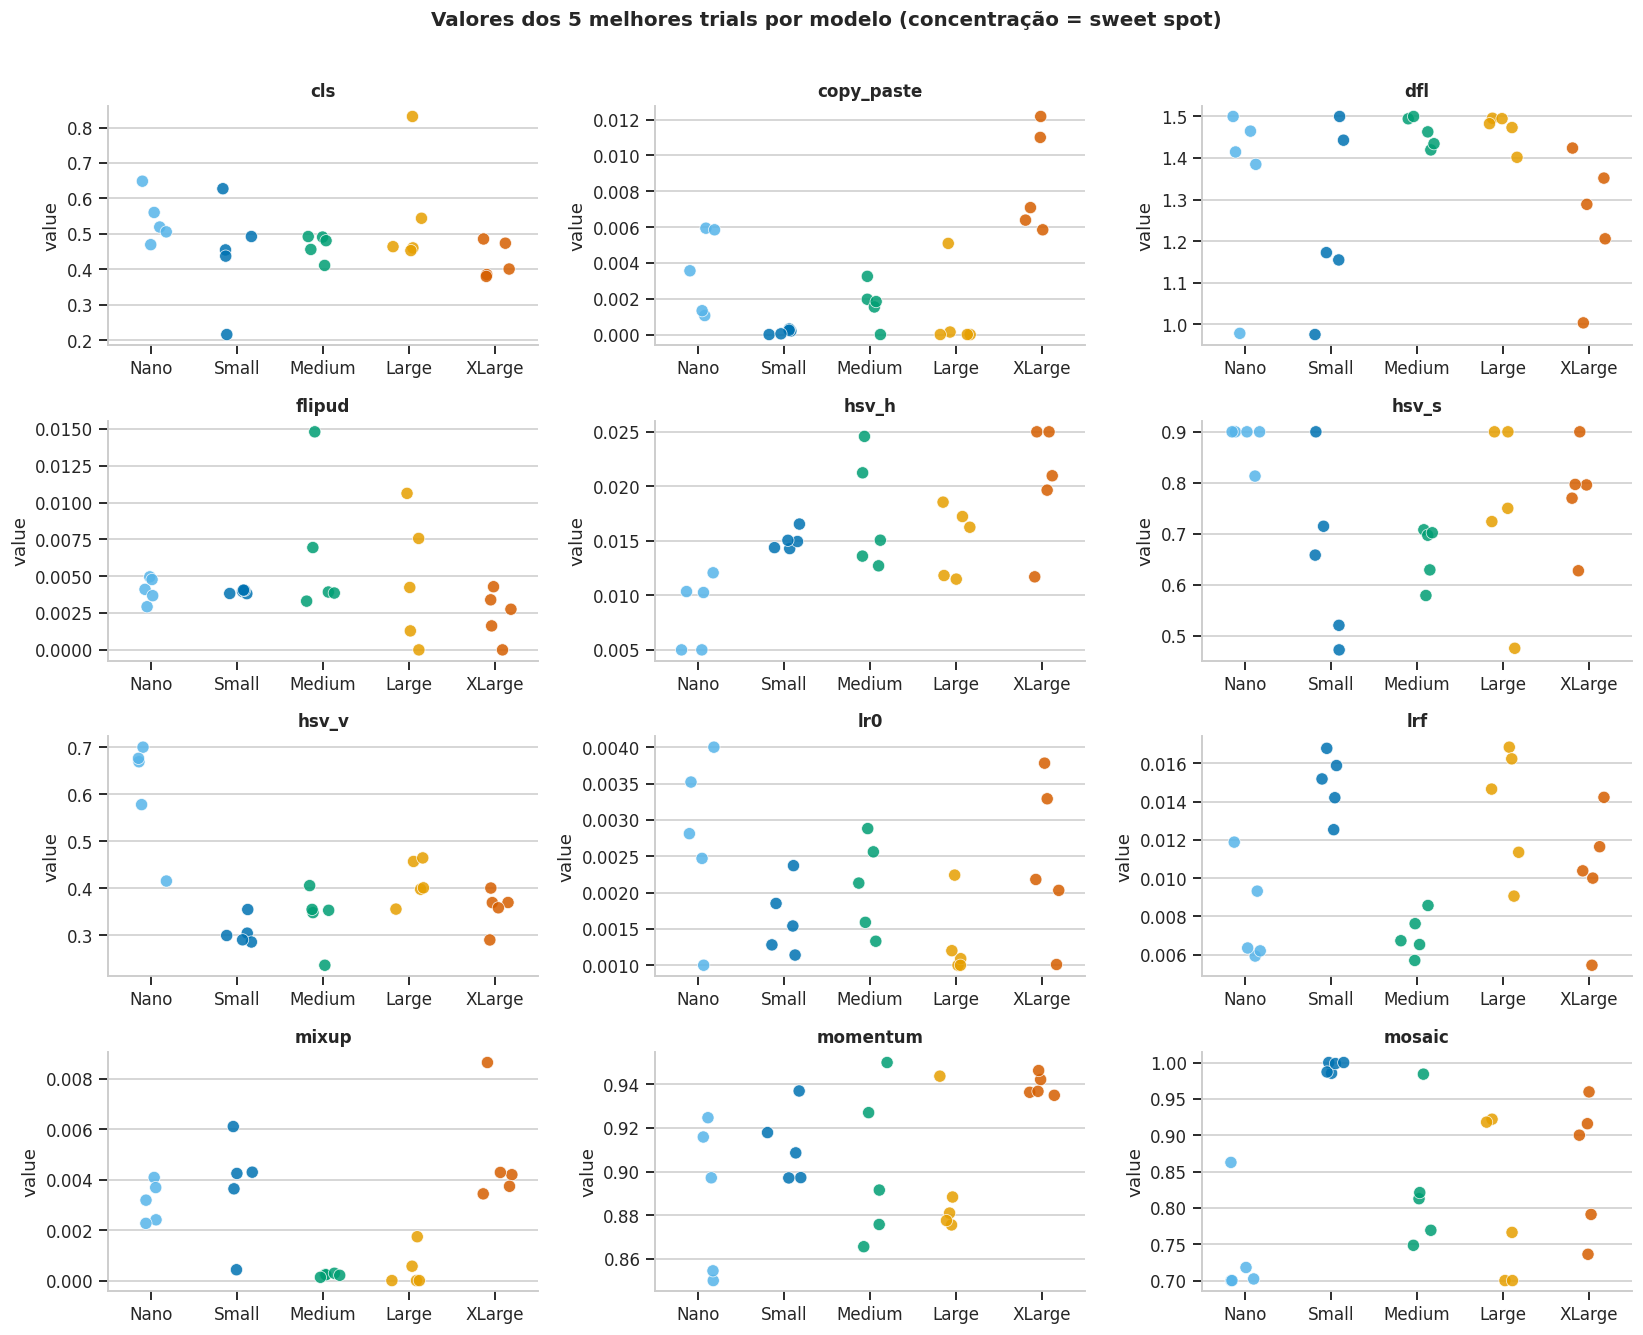

In [61]:
TOPK = 5
top_rows = []
for m in MODELS_PRESENT:
    df = runs[m]["df"]
    top_df = df.sort_values("fitness", ascending=False).head(TOPK)
    for hp in HP_TO_PLOT:
        if hp not in top_df:
            continue
        for v in top_df[hp]:
            top_rows.append({"Model": m, "hp": hp, "value": float(v)})

top_df_long = pd.DataFrame(top_rows)

if not top_df_long.empty:
    g_cols = 3
    g_rows = (len(HP_TO_PLOT) + g_cols - 1) // g_cols
    fig, axes = plt.subplots(g_rows, g_cols, figsize=(15, 3.0 * g_rows), squeeze=False)
    axes_flat = axes.flatten()
    for i, hp in enumerate(HP_TO_PLOT):
        ax = axes_flat[i]
        sub = top_df_long[top_df_long["hp"] == hp]
        if sub.empty:
            ax.axis("off"); continue
        sns.stripplot(data=sub, x="Model", y="value",
                      hue="Model", ax=ax, palette=MODEL_PALETTE,
                      order=MODELS_PRESENT, jitter=0.2, size=8,
                      alpha=0.85, edgecolor="white", linewidth=0.5,
                      legend=False)
        ax.set_title(hp, fontsize=11)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=0)
    for j in range(len(HP_TO_PLOT), len(axes_flat)):
        axes_flat[j].axis("off")
    fig.suptitle(f"Valores dos {TOPK} melhores trials por modelo (concentração = sweet spot)",
                 y=1.01, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


## 8. Correlação hp × fitness

Pearson e Spearman entre cada hp e a fitness do trial, **dentro de cada
modelo**. |corr| alto = aquele hp realmente importa para o tamanho.
|corr| ≈ 0 = o GA variou esse hp sem efeito mensurável (provavelmente
não vale tunar).


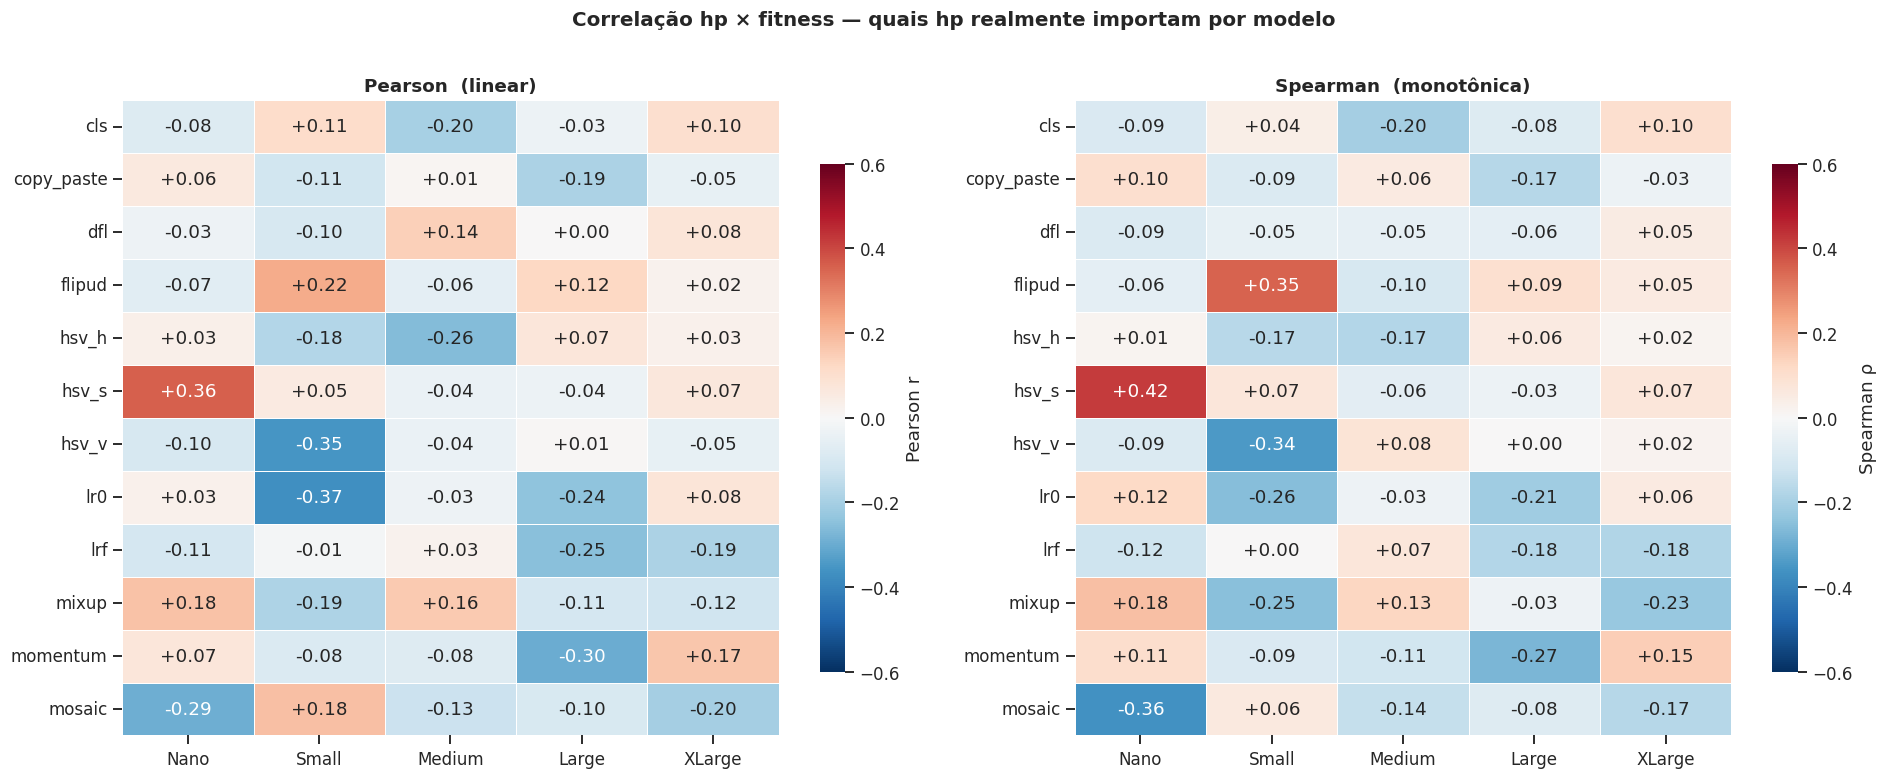

In [62]:
corr_rows = []
for m in MODELS_PRESENT:
    df = runs[m]["df"]
    for hp in HP_TO_PLOT:
        if hp not in df or df[hp].nunique() < 2:
            continue
        sub = df[[hp, "fitness"]].dropna()
        if len(sub) < 4:
            continue
        rho_p = sub.corr(method="pearson").iloc[0, 1]
        rho_s = sub.corr(method="spearman").iloc[0, 1]
        corr_rows.append({"Model": m, "hp": hp,
                          "Pearson": rho_p, "Spearman": rho_s})

corr_df = pd.DataFrame(corr_rows)
if not corr_df.empty:
    pivot_p = corr_df.pivot(index="hp", columns="Model", values="Pearson").reindex(columns=MODELS_PRESENT)
    pivot_s = corr_df.pivot(index="hp", columns="Model", values="Spearman").reindex(columns=MODELS_PRESENT)

    fig, axes = plt.subplots(1, 2, figsize=(2 * (1.6 * len(MODELS_PRESENT)) + 1.5, 0.45 * len(pivot_p) + 1.6))
    sns.heatmap(pivot_p, ax=axes[0], cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
                annot=True, fmt="+.2f", linewidths=0.4, linecolor="white",
                cbar_kws={"label": "Pearson r", "shrink": 0.8})
    axes[0].set_title("Pearson  (linear)")
    sns.heatmap(pivot_s, ax=axes[1], cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
                annot=True, fmt="+.2f", linewidths=0.4, linecolor="white",
                cbar_kws={"label": "Spearman ρ", "shrink": 0.8})
    axes[1].set_title("Spearman  (monotônica)")
    for a in axes:
        a.set_xlabel(""); a.set_ylabel("")
    fig.suptitle("Correlação hp × fitness — quais hp realmente importam por modelo",
                 y=1.01, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


## 9. Hp campeão normalizado pelo `SEARCH_SPACE` por modelo

Para cada hp do `tune_isic_2018_task_1.py`, mostra o valor campeão
normalizado para `[0, 1]` dentro do range do search space. Heatmap deixa
óbvio: modelos pequenos preferem `lr0` mais baixo? `degrees` mais alto
em modelos grandes? etc.


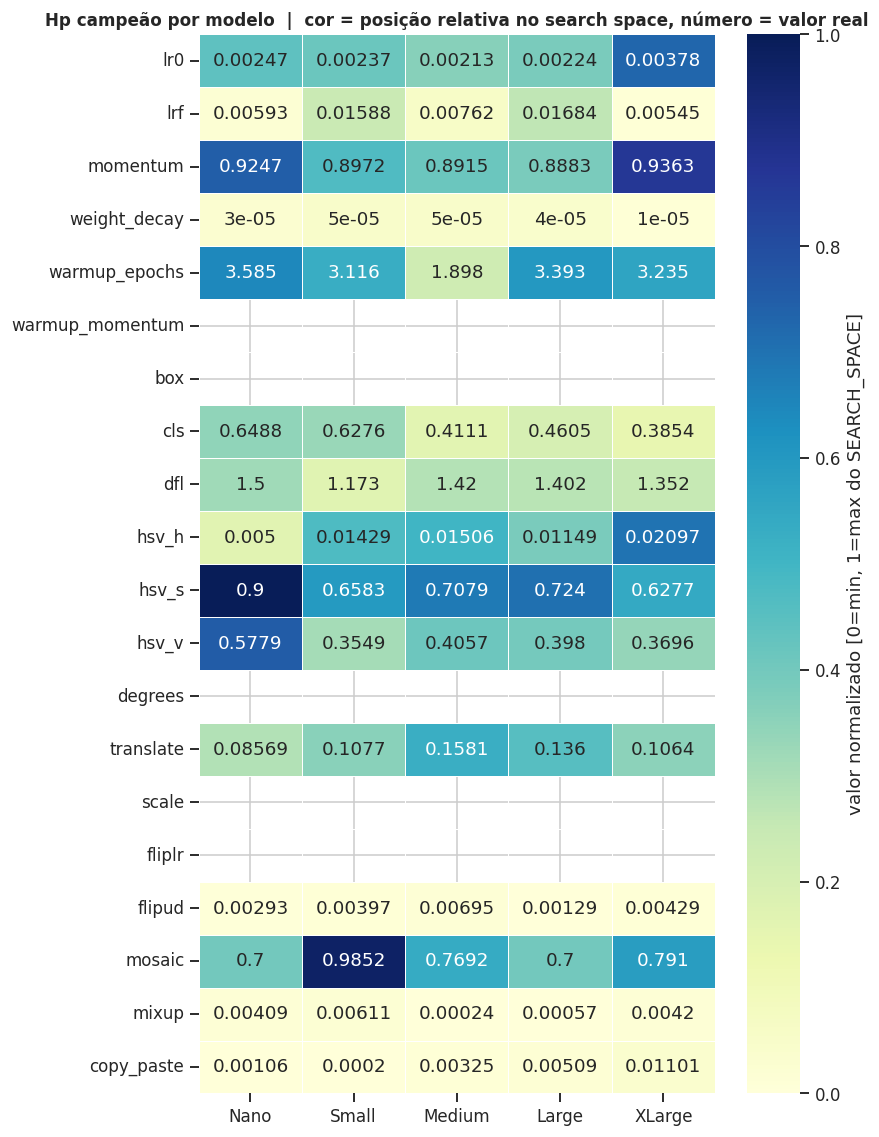

In [63]:
# Espelho do SEARCH_SPACE — mantém em sync com tune_isic_2018_task_1.py.
SEARCH_SPACE = {
    "lr0":            (5e-4, 5e-3),
    "lrf":            (0.005, 0.05),
    "momentum":       (0.85, 0.95),
    "weight_decay":   (0.0, 0.001),
    "warmup_epochs":  (1.0, 5.0),
    "warmup_momentum": (0.5, 0.95),
    "box":            (3.0, 12.0),
    "cls":            (0.2, 1.5),
    "dfl":            (0.8, 3.0),
    "hsv_h":          (0.0, 0.03),
    "hsv_s":          (0.3, 0.9),
    "hsv_v":          (0.2, 0.7),
    "degrees":        (0.0, 30.0),
    "translate":      (0.0, 0.3),
    "scale":          (0.2, 0.7),
    "fliplr":         (0.0, 0.6),
    "flipud":         (0.0, 0.5),
    "mosaic":         (0.5, 1.0),
    "mixup":          (0.0, 0.3),
    "copy_paste":     (0.0, 0.3),
}


def normalize(v: float, lo: float, hi: float) -> float:
    if hi == lo:
        return 0.5
    return float(np.clip((v - lo) / (hi - lo), 0.0, 1.0))


norm_rows = []
for m in MODELS_PRESENT:
    hp_dict = runs[m]["best_hp"]
    for hp, rng in SEARCH_SPACE.items():
        if hp not in hp_dict:
            continue
        norm_rows.append({"Model": m, "hp": hp,
                          "value":      hp_dict[hp],
                          "norm_value": normalize(hp_dict[hp], rng[0], rng[1])})

if norm_rows:
    norm_df = pd.DataFrame(norm_rows)
    annot = norm_df.pivot(index="hp", columns="Model", values="value").reindex(
        index=list(SEARCH_SPACE), columns=MODELS_PRESENT)
    norm_pivot = norm_df.pivot(index="hp", columns="Model", values="norm_value").reindex(
        index=list(SEARCH_SPACE), columns=MODELS_PRESENT)

    fig, ax = plt.subplots(figsize=(max(6, 1.6 * len(MODELS_PRESENT)), 0.45 * len(SEARCH_SPACE) + 1.5))
    sns.heatmap(
        norm_pivot, annot=annot, fmt=".4g",
        cmap="YlGnBu", vmin=0.0, vmax=1.0,
        cbar_kws={"label": "valor normalizado [0=min, 1=max do SEARCH_SPACE]"},
        linewidths=0.5, linecolor="white", ax=ax,
    )
    ax.set_title(
        "Hp campeão por modelo  |  cor = posição relativa no search space, número = valor real",
        fontsize=11,
    )
    ax.set_xlabel(""); ax.set_ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("Sem dados de best_hyperparameters.yaml.")


## 10. Δ campeão vs default v7

Quanto cada hp se moveu em relação ao default que vínhamos usando na
v7. Verde = subiu, vermelho = desceu. Linhas marcadas no extremo do
search space podem indicar que o range escolhido foi estreito demais.


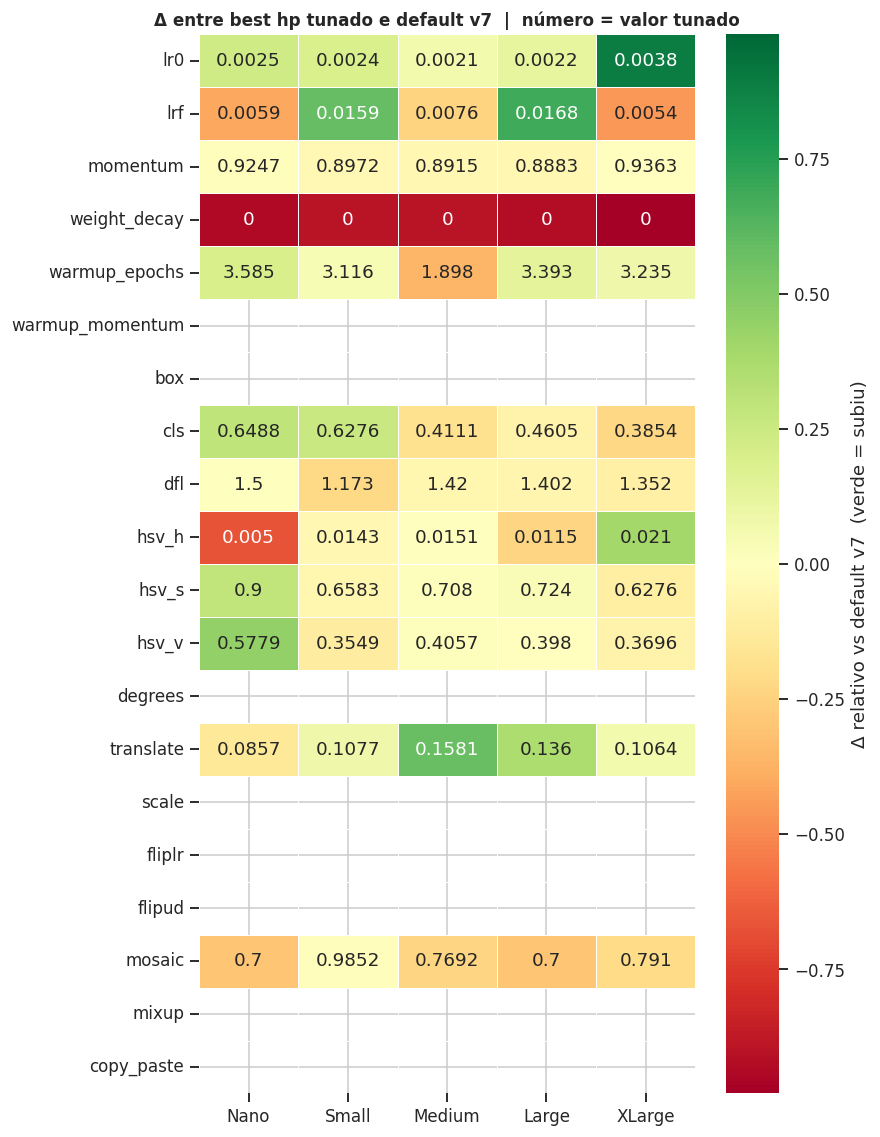

In [64]:
# Defaults v7 (espelha train_isic_2018_task_1_v7.py).
DEFAULTS_V7 = {
    "lr0": 0.002, "lrf": 0.01, "momentum": 0.937, "weight_decay": 0.0005,
    "warmup_epochs": 3.0, "warmup_momentum": 0.8,
    "box": 7.5, "cls": 0.5, "dfl": 1.5,
    "hsv_h": 0.015, "hsv_s": 0.7, "hsv_v": 0.4,
    "degrees": 0.0, "translate": 0.1, "scale": 0.5,
    "fliplr": 0.5, "flipud": 0.0,
    "mosaic": 1.0, "mixup": 0.0, "copy_paste": 0.0,
}

delta_rows = []
for m in MODELS_PRESENT:
    hp_dict = runs[m]["best_hp"]
    for hp, default in DEFAULTS_V7.items():
        if hp not in hp_dict or default == 0:
            d = hp_dict.get(hp, np.nan) - default if hp in hp_dict else np.nan
            pct = np.nan if default == 0 else d
        else:
            d = hp_dict[hp] - default
            pct = d / default
        delta_rows.append({"Model": m, "hp": hp,
                          "default": default, "best": hp_dict.get(hp, np.nan),
                          "delta": d, "pct": pct})

if delta_rows:
    delta_df = pd.DataFrame(delta_rows)
    pivot_pct = delta_df.pivot(index="hp", columns="Model", values="pct").reindex(
        index=list(DEFAULTS_V7), columns=MODELS_PRESENT)
    pivot_best = delta_df.pivot(index="hp", columns="Model", values="best").reindex(
        index=list(DEFAULTS_V7), columns=MODELS_PRESENT)

    fig, ax = plt.subplots(figsize=(max(6, 1.6 * len(MODELS_PRESENT)), 0.45 * len(DEFAULTS_V7) + 1.5))
    vmax = float(np.nanmax(np.abs(pivot_pct.values))) if pivot_pct.notna().any().any() else 1.0
    sns.heatmap(
        pivot_pct, annot=pivot_best.round(4), fmt=".4g",
        cmap="RdYlGn", center=0, vmin=-vmax, vmax=vmax,
        cbar_kws={"label": "Δ relativo vs default v7  (verde = subiu)"},
        linewidths=0.5, linecolor="white", ax=ax,
    )
    ax.set_title("Δ entre best hp tunado e default v7  |  número = valor tunado",
                 fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


## 11. Concordância entre modelos — `corr` dos hp campeões

Correlação entre os vetores de hp campeões de diferentes modelos. Alta
correlação (> 0.7) sugere que **um único set de hp pode servir vários
tamanhos**. Baixa = cada tamanho precisa do próprio set.


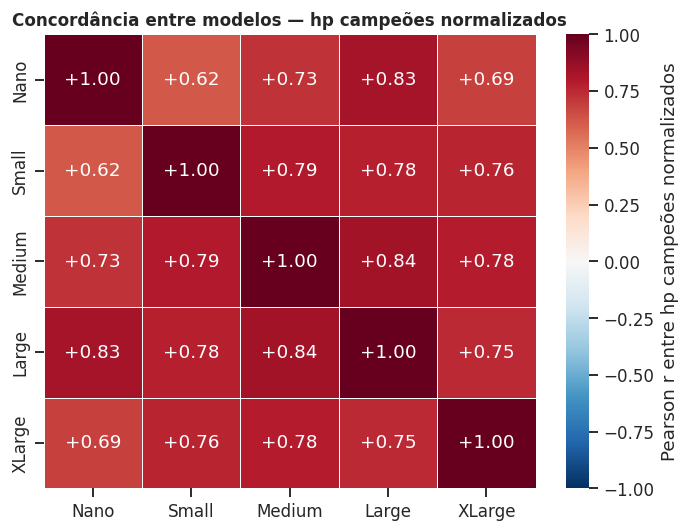

In [65]:
if len(MODELS_PRESENT) >= 2 and norm_rows:
    cross = norm_pivot.corr(method="pearson")
    fig, ax = plt.subplots(figsize=(0.9 * len(MODELS_PRESENT) + 2, 0.7 * len(MODELS_PRESENT) + 1.5))
    sns.heatmap(cross, annot=True, fmt="+.2f", cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, linewidths=0.5, linecolor="white",
                cbar_kws={"label": "Pearson r entre hp campeões normalizados"},
                ax=ax)
    ax.set_title("Concordância entre modelos — hp campeões normalizados", fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("Precisa de ≥2 modelos com best_hp para concordância cruzada.")


## 12. Insights automáticos

In [66]:
insights = []

# 1. Best fitness absoluto
overall = max(MODELS_PRESENT, key=lambda m: runs[m]["df"]["fitness"].max())
insights.append(
    f"**Champion absoluto**: `{overall}` com fitness = "
    f"**{runs[overall]['df']['fitness'].max():.4f}** "
    f"(iter {int(runs[overall]['df'].loc[runs[overall]['df']['fitness'].idxmax(), 'iteration'])})."
)

# 2. Convergência: quem ainda estava melhorando no fim
still_improving = [m for m in MODELS_PRESENT
                   if stats_for(runs[m]["df"])["Improved last 25%"]]
if still_improving:
    insights.append(
        f"**Ainda melhorando no final**: {still_improving}. "
        f"Considerar mais iterações para esses modelos."
    )

# 3. Hp mais consistentes entre modelos (menor std dos valores normalizados)
if norm_rows:
    spread = norm_pivot.std(axis=1).sort_values()
    most_consistent = spread.head(3).index.tolist()
    most_variable = spread.tail(3).index.tolist()
    insights.append(
        f"**Mais consistentes entre modelos** (todos convergem para valor parecido): "
        f"{most_consistent}."
    )
    insights.append(
        f"**Mais variáveis entre modelos** (cada tamanho precisa de valor diferente): "
        f"{most_variable}."
    )

# 4. Correlações fortes hp × fitness (média sobre modelos com |r| > 0.3)
if not corr_df.empty:
    abs_p = corr_df.assign(abs_p=corr_df["Pearson"].abs())
    strong = abs_p.groupby("hp")["abs_p"].mean().sort_values(ascending=False).head(3)
    weak   = abs_p.groupby("hp")["abs_p"].mean().sort_values(ascending=False).tail(3)
    insights.append(
        f"**Hp que mais afetam fitness** (média |r| Pearson alta): "
        f"{strong.index.tolist()}."
    )
    insights.append(
        f"**Hp com efeito mensurável fraco** (provavelmente não vale tunar): "
        f"{weak.index.tolist()}."
    )

# 5. Recomendação operacional
if len(MODELS_PRESENT) >= 2:
    cross_avg = (cross.values[np.triu_indices_from(cross.values, k=1)].mean()
                 if 'cross' in dir() and cross is not None else None)
    if cross_avg is not None:
        if cross_avg > 0.7:
            insights.append(
                f"**Concordância alta entre modelos** (média r = {cross_avg:.2f}): "
                f"um único set de hp pode servir múltiplos tamanhos."
            )
        elif cross_avg < 0.3:
            insights.append(
                f"**Concordância baixa entre modelos** (média r = {cross_avg:.2f}): "
                f"cada tamanho precisa do próprio best_hp."
            )

display(Markdown("### Destaques\n\n" + "\n\n".join(f"- {x}" for x in insights)))


### Destaques

- **Champion absoluto**: `Small` com fitness = **1.4616** (iter 11).

- **Ainda melhorando no final**: ['Nano']. Considerar mais iterações para esses modelos.

- **Mais consistentes entre modelos** (todos convergem para valor parecido): ['flipud', 'mixup', 'copy_paste'].

- **Mais variáveis entre modelos** (cada tamanho precisa de valor diferente): ['degrees', 'scale', 'fliplr'].

- **Hp que mais afetam fitness** (média |r| Pearson alta): ['mosaic', 'lr0', 'mixup'].

- **Hp com efeito mensurável fraco** (provavelmente não vale tunar): ['flipud', 'copy_paste', 'dfl'].

- **Concordância alta entre modelos** (média r = 0.76): um único set de hp pode servir múltiplos tamanhos.

## 13. Export — tabela consolidada para CSV

In [67]:
rows_export = []
for m in MODELS_PRESENT:
    hp_dict = runs[m]["best_hp"]
    df = runs[m]["df"]
    rows_export.append({
        "Model": m,
        "Best fitness": df["fitness"].max(),
        "Best iter": int(df["iteration"].iloc[df["fitness"].idxmax()]),
        "N trials": len(df),
        **hp_dict,
    })
export = pd.DataFrame(rows_export).set_index("Model").reindex(MODELS_PRESENT)

out = BASE_DIR / "logs" / "analyze_hpo_results_summary.csv"
try:
    export.to_csv(out)
    print(f"Salvo: {out}")
except OSError as e:
    print(f"(sem permissão para salvar em {out}: {e})")

display(export.style.format(precision=4, na_rep="—"))


Salvo: /home/antoniovinicius/projects/sandbox_yolo26/logs/analyze_hpo_results_summary.csv


,Best fitness,Best iter,N trials,lr0,lrf,momentum,weight_decay,warmup_epochs,cls,dfl,hsv_h,hsv_s,hsv_v,translate,flipud,mosaic,mixup,copy_paste
Model,,,,,,,,,,,,,,,,,,
Nano,1.4253,42,50,0.0025,0.0059,0.9247,0.0000,3.5853,0.6488,1.5000,0.0050,0.9000,0.5779,0.0857,0.0029,0.7000,0.0041,0.0011
Small,1.4616,11,50,0.0024,0.0159,0.8972,0.0001,3.1161,0.6276,1.1725,0.0143,0.6583,0.3549,0.1077,0.0040,0.9852,0.0061,0.0002
Medium,1.4571,25,50,0.0021,0.0076,0.8915,0.0001,1.8982,0.4111,1.4196,0.0151,0.7079,0.4057,0.1581,0.0069,0.7692,0.0002,0.0032
Large,1.4601,11,50,0.0022,0.0168,0.8883,0.0000,3.3929,0.4605,1.4018,0.0115,0.7240,0.3980,0.1360,0.0013,0.7000,0.0006,0.0051
XLarge,1.4396,11,35,0.0038,0.0054,0.9363,0.0000,3.2346,0.3854,1.3518,0.0210,0.6277,0.3696,0.1064,0.0043,0.7910,0.0042,0.0110
